In [30]:
import pandas as pd

df = pd.read_csv(r"C:\Users\tlili\OneDrive\Bureau\Bootcamp\AI-powered-cryptocurrency-market-analysis-and-decision-support-system\data\raw\crypto_raw.csv", parse_dates=["timestamp"])

print(f"Shape      : {df.shape}")
print(f"Coins      : {df['coin'].value_counts().to_dict()}")
print(f"Date range : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Dtypes     :\n{df.dtypes}")
print(f"\nSample:")
df.head()

Shape      : (6346, 9)
Coins      : {'btc': 3329, 'eth': 3017}
Date range : 2017-01-01 → 2026-02-11
Dtypes     :
timestamp     datetime64[ns]
price                float64
volume                 int64
coin                  object
spy_return           float64
dxy_return           float64
vix                  float64
vix_change           float64
fear_greed           float64
dtype: object

Sample:


,timestamp,price,volume,coin,spy_return,dxy_return,vix,vix_change,fear_greed
0,2017-01-01,998.325012,147775008,btc,NaN,NaN,NaN,NaN,NaN
1,2017-01-02,1021.750000,222184992,btc,NaN,NaN,NaN,NaN,NaN
2,2017-01-03,1043.839966,185168000,btc,NaN,NaN,12.85,NaN,NaN
3,2017-01-04,1154.729980,344945984,btc,0.005932,-0.004954,11.85,-1.00,NaN
4,2017-01-05,1013.380005,510199008,btc,-0.000795,-0.011556,11.67,-0.18,NaN


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6346 entries, 0 to 6345
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   6346 non-null   datetime64[ns]
 1   price       6346 non-null   float64       
 2   volume      6346 non-null   int64         
 3   coin        6346 non-null   object        
 4   spy_return  4363 non-null   float64       
 5   dxy_return  4367 non-null   float64       
 6   vix         4364 non-null   float64       
 7   vix_change  4363 non-null   float64       
 8   fear_greed  5858 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 446.3+ KB


In [32]:
#missing values
nan_counts = df.isna().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
missing    = pd.DataFrame({"missing": nan_counts, "pct_%": nan_pct})
print(missing[missing["missing"] > 0].sort_values("pct_%", ascending=False))

            missing  pct_%
spy_return     1983  31.25
vix_change     1983  31.25
vix            1982  31.23
dxy_return     1979  31.18
fear_greed      488   7.69


- spy_return, dxy_return, vix, vix_change — 31% NaN is purely structural (weekends/holidays). A forward-fill of max 3 days resolves this completely and cleanly. These are strong macro signals, we will keep them and handel them later in the preprocessing stage.
- fear_greed — 7.7% NaN only because it starts Feb 2018. Everything after that is solid. Essential sentiment signal, we will keep it and handel it later in the preprocessing stage.


In [13]:
#BASIC STATISTICS
print(df.describe().T.round(4))

             count                           mean                  min  \
timestamp     6346  2021-10-05 03:57:48.389536512  2017-01-01 00:00:00   
price       6346.0                   18766.820719            84.308296   
volume      6346.0             21543065386.095966           60851700.0   
spy_return  4363.0                       0.000545            -0.115886   
dxy_return  4367.0                       -0.00001            -0.021394   
vix         4364.0                      19.145575                 9.14   
vix_change  4363.0                       0.002904           -18.710003   
fear_greed  5858.0                      46.856606                  5.0   

                            25%                  50%                  75%  \
timestamp   2019-08-08 00:00:00  2021-10-09 00:00:00  2023-12-11 00:00:00   
price               1628.694519          3903.647827         25846.766113   
volume            7299787388.25        16668157626.5        30062290253.5   
spy_return            -0.

- Price — massive range ($84 → $124k), highly skewed. Will need log transformation before modeling.
important for Raw price:
   → compute all rolling/technical features  (MA, MACD, RSI, Bollinger...)
   → then log transform price & volume
   → then scale everything before model training
- Volume — same story, std > mean. Expect heavy right skew.
- SPY/DXY returns — well-behaved, near-zero mean, small std. Ready to use as-is.
- VIX — mean ~19, max 82 (COVID spike). The vix_change std of 2 with extremes at ±24 signals fat tails — worth capping outliers in preprocessing.
- Fear & Greed — mean ~47 (slightly fear-leaning), full range 5→95 used. Healthy distribution.


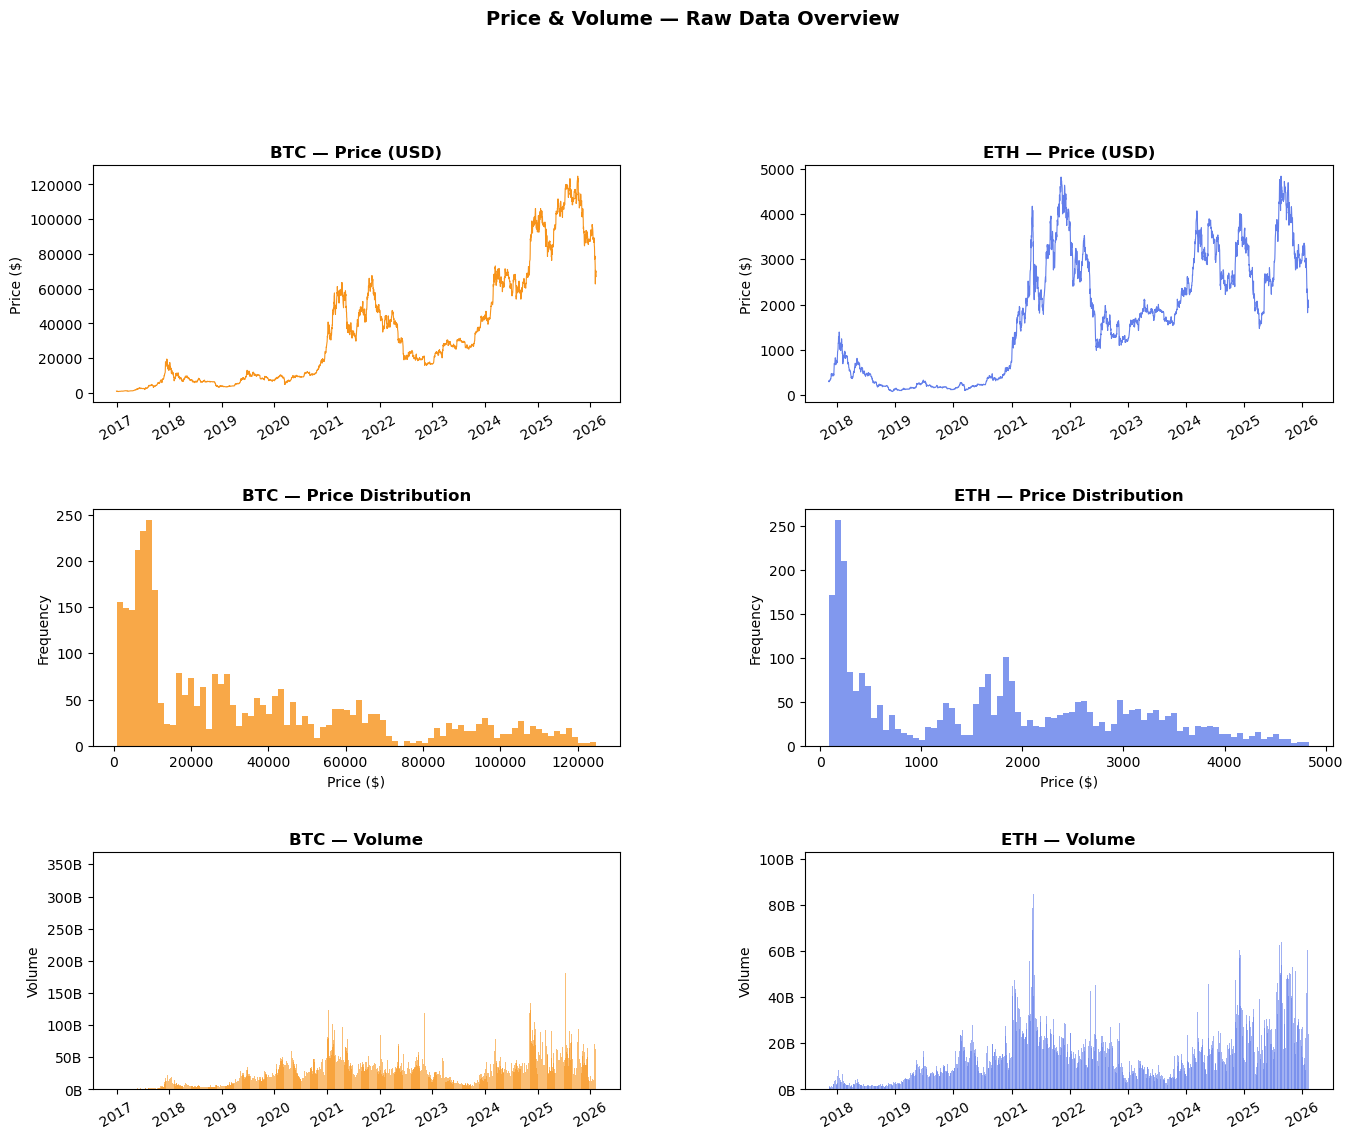

In [25]:
# EDA — PRICE & VOLUME VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

colors = {"btc": "#F7931A", "eth": "#627EEA"}

for i, coin in enumerate(["btc", "eth"]):
    sub = df[df["coin"] == coin].set_index("timestamp")

    # ── Price time series
    ax1 = fig.add_subplot(gs[0, i])
    ax1.plot(sub.index, sub["price"], color=colors[coin], linewidth=0.8)
    ax1.set_title(f"{coin.upper()} — Price (USD)", fontweight="bold")
    ax1.set_ylabel("Price ($)")
    ax1.tick_params(axis="x", rotation=30)

    # ── Price distribution
    ax2 = fig.add_subplot(gs[1, i])
    ax2.hist(sub["price"], bins=80, color=colors[coin], edgecolor="none", alpha=0.8)
    ax2.set_title(f"{coin.upper()} — Price Distribution", fontweight="bold")
    ax2.set_xlabel("Price ($)")
    ax2.set_ylabel("Frequency")

    # ── Volume time series
    ax3 = fig.add_subplot(gs[2, i])
    ax3.bar(sub.index, sub["volume"], color=colors[coin], alpha=0.6, width=1.5)
    ax3.set_title(f"{coin.upper()} — Volume", fontweight="bold")
    ax3.set_ylabel("Volume")
    ax3.tick_params(axis="x", rotation=30)
    ax3.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e9:.0f}B")
    )

plt.suptitle("Price & Volume — Raw Data Overview", fontsize=14, fontweight="bold", y=1.01)
plt.show()


In [14]:
print(type(df))
df.info()

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6346 entries, 0 to 6345
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   6346 non-null   datetime64[ns]
 1   price       6346 non-null   float64       
 2   volume      6346 non-null   int64         
 3   coin        6346 non-null   object        
 4   spy_return  4363 non-null   float64       
 5   dxy_return  4367 non-null   float64       
 6   vix         4364 non-null   float64       
 7   vix_change  4363 non-null   float64       
 8   fear_greed  5858 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 446.3+ KB


In [17]:
#duplicates
dup_total = df.duplicated().sum()
dup_ts    = df.duplicated(subset=["timestamp", "coin"]).sum()
print(f"  Total duplicate rows     : {dup_total}")
print(f"  Duplicate (timestamp+coin): {dup_ts}")

  Total duplicate rows     : 0
  Duplicate (timestamp+coin): 0


In [18]:
#DATE CONTINUITY CHECK
for coin in df["coin"].unique():
    sub   = df[df["coin"] == coin].set_index("timestamp").sort_index()
    gaps  = sub.index.to_series().diff().dt.days.dropna()
    jumps = gaps[gaps > 1]
    print(f"\n  {coin.upper()}")
    print(f"    Rows          : {len(sub)}")
    print(f"    Start → End   : {sub.index.min().date()} → {sub.index.max().date()}")
    print(f"    Gaps > 1 day  : {len(jumps)}")
    if len(jumps) > 0:
        print(f"    Largest gap   : {int(jumps.max())} days on {jumps.idxmax().date()}")

print("\n" + "=" * 60)
print("6. SAMPLE — HEAD & TAIL PER COIN")
print("=" * 60)
print("\n  --- HEAD ---")
print(df.groupby("coin").head(3).to_string(index=False))
print("\n  --- TAIL ---")
print(df.groupby("coin").tail(3).to_string(index=False))


  BTC
    Rows          : 3329
    Start → End   : 2017-01-01 → 2026-02-11
    Gaps > 1 day  : 0

  ETH
    Rows          : 3017
    Start → End   : 2017-11-09 → 2026-02-11
    Gaps > 1 day  : 0

6. SAMPLE — HEAD & TAIL PER COIN

  --- HEAD ---
 timestamp       price    volume coin  spy_return  dxy_return   vix  vix_change  fear_greed
2017-01-01  998.325012 147775008  btc         NaN         NaN   NaN         NaN         NaN
2017-01-02 1021.750000 222184992  btc         NaN         NaN   NaN         NaN         NaN
2017-01-03 1043.839966 185168000  btc         NaN         NaN 12.85         NaN         NaN
2017-11-09  320.884003 893249984  eth   -0.003634   -0.004543 10.50        0.72         NaN
2017-11-10  299.252991 885985984  eth   -0.000310   -0.000530 11.29        0.79         NaN
2017-11-11  314.681000 842300992  eth         NaN         NaN   NaN         NaN         NaN

  --- TAIL ---
 timestamp        price      volume coin  spy_return  dxy_return       vix  vix_change  fear_g

In [19]:
#data type check 
(df.dtypes)

timestamp     datetime64[ns]
price                float64
volume                 int64
coin                  object
spy_return           float64
dxy_return           float64
vix                  float64
vix_change           float64
fear_greed           float64
dtype: object

## Step 3: Data preprocessing 

In [20]:
# round values
df["price"]      = df["price"].round(2)
df["volume"]     = df["volume"].round(0).astype("Int64")  # nullable int (keeps NaN safe)
df["spy_return"] = df["spy_return"].round(6)
df["dxy_return"] = df["dxy_return"].round(6)
df["vix"]        = df["vix"].round(2)
df["vix_change"] = df["vix_change"].round(2)
df["fear_greed"] = df["fear_greed"].round(0).astype("Int64")

print(df.dtypes)
print(f"\nSample:")
print(df.groupby("coin").head(3).to_string(index=False))

timestamp     datetime64[ns]
price                float64
volume                 Int64
coin                  object
spy_return           float64
dxy_return           float64
vix                  float64
vix_change           float64
fear_greed             Int64
dtype: object

Sample:
 timestamp   price    volume coin  spy_return  dxy_return   vix  vix_change  fear_greed
2017-01-01  998.33 147775008  btc         NaN         NaN   NaN         NaN        <NA>
2017-01-02 1021.75 222184992  btc         NaN         NaN   NaN         NaN        <NA>
2017-01-03 1043.84 185168000  btc         NaN         NaN 12.85         NaN        <NA>
2017-11-09  320.88 893249984  eth   -0.003634   -0.004543 10.50        0.72        <NA>
2017-11-10  299.25 885985984  eth   -0.000310   -0.000530 11.29        0.79        <NA>
2017-11-11  314.68 842300992  eth         NaN         NaN   NaN         NaN        <NA>


In [21]:
#sorting
df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)
df.head()

,timestamp,price,volume,coin,spy_return,dxy_return,vix,vix_change,fear_greed
0,2017-01-01,998.33,147775008,btc,NaN,NaN,NaN,NaN,<NA>
1,2017-01-02,1021.75,222184992,btc,NaN,NaN,NaN,NaN,<NA>
2,2017-01-03,1043.84,185168000,btc,NaN,NaN,12.85,NaN,<NA>
3,2017-01-04,1154.73,344945984,btc,0.005932,-0.004954,11.85,-1.00,<NA>
4,2017-01-05,1013.38,510199008,btc,-0.000795,-0.011556,11.67,-0.18,<NA>


In [50]:
#handeling nans
macro_cols = ["spy_return", "dxy_return", "vix", "vix_change"]
df[macro_cols] = (
    df.groupby("coin")[macro_cols]
      .transform(lambda x: x.ffill(limit=3))
)

df["fear_greed"] = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.ffill())
)

p01 = df["vix_change"].quantile(0.01)
p99 = df["vix_change"].quantile(0.99)
df["vix_change"] = df["vix_change"].clip(lower=p01, upper=p99)

print("NaN check after preprocessing:")
print(df[["spy_return","dxy_return","vix","vix_change","fear_greed"]].isna().sum())

NaN check after preprocessing:
spy_return      3
dxy_return      3
vix             2
vix_change      3
fear_greed    480
dtype: int64


- for fear and greed index The raw 0-100 score is continuous but the meaning is categorical (extreme fear, fear, neutral, greed, extreme greed). We will create a new categorical column based on the score ranges to capture this sentiment more explicitly for the model.

In [48]:
# ── Fear & Greed : sentiment category
bins   = [0, 24, 44, 55, 74, 100]
labels = [0, 1, 2, 3, 4]          # 0=Extreme Fear → 4=Extreme Greed

df["fear_greed_cat"] = pd.cut(
    df["fear_greed"],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype("Int64")

# ── Quick distribution check
print("Fear & Greed category distribution:")
print(df["fear_greed_cat"].value_counts().sort_index().rename({
    0: "Extreme Fear",
    1: "Fear",
    2: "Neutral",
    3: "Greed",
    4: "Extreme Greed"
}))

Fear & Greed category distribution:
fear_greed_cat
Extreme Fear     1148
Fear             1682
Neutral           968
Greed            1400
Extreme Greed     660
Name: count, dtype: Int64


## Step 4: Feature engineering 

* We will create a new feature that measures change in price from one day to the next, providing insights into the coin's daily performance and volatility​​ 
- log returns= ln(Price today/Price yesterday)
- this feature will replace the price_change_24h and price_change_percentage_24h features which are snapshot values and remain constant across the historical dataset.

In [37]:
import numpy as np

df = df.sort_values(["coin", "timestamp"])

df["log_return_1d"] = (
    df.groupby("coin")["price"]
    .transform(lambda x: np.log(x / x.shift(1)))
)


* we will create a new feature to mesure the rolling risk of the coin in a given period (7 days, 14 days) 
So instead of just knowing today s return, we know how unstable or risky the coin is in the last period. 

In [38]:
 df["volatility_7d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=7)
    .std()
    .reset_index(level=0, drop=True)
)

df["volatility_14d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=14)
    .std()
    .reset_index(level=0, drop=True)
)

* we will create a new feature for the RSI 14 day (relative strength index) which evaluates the overbought or oversold condition of a coin base on its recent price movements

In [39]:
window = 14

delta = df.groupby("coin")["price"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)
avg_loss = loss.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)

rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))

 - we will add a new feature fo the Moving averages that smooths out price data by taking the average price over a set period of time 
 - short term MA Tracks short-term momentum, reacts quickly to price changes. Good for:short-term signals,detecting quick trend shifts
 - Medium term MA Smoother than MA7 Confirms trends that last longer than just a few days. Often used with MA7 to detect crossovers. if MA7 crossing above MA14 → bullish momentum. if MA7 crossing below MA14 → bearish momentum
 - long term MA Identifies the overall market direction.if price above MA30 → long-term bullish bias. if price below MA30 → long-term bearish bias
 - Price relative to MA7 (normalized) gives the percentage distance between price and MA7 or MA30 indicating . if large positive → possibly overbought. if arge negative → possibly oversold
 

In [52]:
# MAs 
df["ma_7"] = df.groupby("coin")["price"].rolling(7).mean().reset_index(level=0, drop=True)
df["ma_14"] = df.groupby("coin")["price"].rolling(14).mean().reset_index(level=0, drop=True)
df["ma_30"] = df.groupby("coin")["price"].rolling(30).mean().reset_index(level=0, drop=True)

# Price relative to MA (normalized)
df["price_to_ma7"] = (df["price"] - df["ma_7"]) / df["ma_7"]
df["price_to_ma30"] = (df["price"] - df["ma_30"]) / df["ma_30"]

print(f"Total rows: {len(df)}")
print(df[["timestamp", "coin", "price", "ma_7", "ma_14", "ma_30", "price_to_ma7", "price_to_ma30"]].head(35)) 

Total rows: 6346
    timestamp coin        price         ma_7       ma_14       ma_30  \
0  2017-01-01  btc   998.325012          NaN         NaN         NaN   
1  2017-01-02  btc  1021.750000          NaN         NaN         NaN   
2  2017-01-03  btc  1043.839966          NaN         NaN         NaN   
3  2017-01-04  btc  1154.729980          NaN         NaN         NaN   
4  2017-01-05  btc  1013.380005          NaN         NaN         NaN   
5  2017-01-06  btc   902.200989          NaN         NaN         NaN   
6  2017-01-07  btc   908.585022  1006.115853         NaN         NaN   
7  2017-01-08  btc   911.198975   993.669277         NaN         NaN   
8  2017-01-09  btc   902.828003   976.680420         NaN         NaN   
9  2017-01-10  btc   907.679016   957.228856         NaN         NaN   
10 2017-01-11  btc   777.757019   903.375575         NaN         NaN   
11 2017-01-12  btc   804.833984   873.583287         NaN         NaN   
12 2017-01-13  btc   823.984009   862.409433   

- we will create a new feature MACD (Moving average convergence divergence) : 
- calculates an Exponential Moving Averages (EMA 12 → fast / short-term momentum, EMA 26 → slow / longer-term momentum)
- Measures the distance between fast and slow momentum and shows who is in control buyers or sellers , higher MACD → strong upward momentum, lower MACD → strong downward momentum
- calculates the signal which is the EMA of the MACD line ( EMA 9) and shows the smoothed momentum trend
- calculates the histogram which is the difference between the MACD line and the signal line and shows the momentum strength and potential reversals ( positive histogram → bullish momentum, negative histogram → bearish momentum)

In [42]:
# MACD INDICATORS
# Calculate EMA 12 and EMA 26
ema_12 = df.groupby("coin")["price"].ewm(span=12, adjust=False).mean().reset_index(level=0, drop=True)
ema_26 = df.groupby("coin")["price"].ewm(span=26, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Line = EMA12 - EMA26
df["macd"] = ema_12 - ema_26

# Signal Line = EMA(9) of MACD
df["macd_signal"] = df.groupby("coin")["macd"].ewm(span=9, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Histogram = MACD - Signal (momentum strength)
df["macd_histogram"] = df["macd"] - df["macd_signal"]

print("MACD indicators added!")

MACD indicators added!


- We will add a new feature Momentum Indicator that Measures how fast price is moving 

In [44]:
# 5-day momentum (short-term velocity)
df["momentum_5d"] = df.groupby("coin")["price"].pct_change(periods=5)

# 10-day momentum (medium-term velocity)
df["momentum_10d"] = df.groupby("coin")["price"].pct_change(periods=10)

# Momentum acceleration (difference between short and medium term)
df["momentum_acceleration"] = df["momentum_5d"] - df["momentum_10d"]

- SPY rolling mean & std (7d)
Instead of just "what did the market return today", we capture "what has the market been doing this week" (trend) and "how unstable has it been" (risk regime). A single day return is noisy  the 7d window smooths it.
- DXY rolling mean (7d)
Same logic  a 7d average of dollar strength is a cleaner regime signal than a single day move. BTC historically moves inverse to DXY.
- VIX rolling mean (14d) + regime flag
- VIX above 20 is the classic threshold between calm and fear markets. The flag turns this into a binary signal the model can use directly. The 14d mean captures sustained fear vs. a one-day spike.
- Fear & Greed rolling mean (7d)
Smooths out daily noise  a week of sustained greed/fear is more meaningful than a single day reading.
Fear & Greed lags (1d and 7d)
- we want the model to know what sentiment was before today, not just what it is today. Lag 1 captures yesterday's mood, lag 7 captures last week's mood. Both help the model learn "when sentiment was X, price did Y the next day" without leaking future information.
In short rolling features add memory, lags add causality

In [51]:

# ── SPY : rolling mean & std (market regime signal)
df["spy_return_ma7"]  = (
    df.groupby("coin")["spy_return"]
      .transform(lambda x: x.rolling(7).mean())
)
df["spy_return_std7"] = (
    df.groupby("coin")["spy_return"]
      .transform(lambda x: x.rolling(7).std())
)

# ── DXY : rolling mean (dollar trend)
df["dxy_return_ma7"]  = (
    df.groupby("coin")["dxy_return"]
      .transform(lambda x: x.rolling(7).mean())
)

# ── VIX : rolling mean + regime flag (above 20 = fear regime)
df["vix_ma14"]        = (
    df.groupby("coin")["vix"]
      .transform(lambda x: x.rolling(14).mean())
)
df["vix_regime"]      = (df["vix"] > 20).astype(int)

# ── Fear & Greed : rolling mean + lag features
df["fear_greed_ma7"]  = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.rolling(7).mean())
)
df["fear_greed_lag1"] = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.shift(1))
)
df["fear_greed_lag7"] = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.shift(7))
)

# ── Sanity check
new_cols = [
    "spy_return_ma7", "spy_return_std7",
    "dxy_return_ma7",
    "vix_ma14", "vix_regime",
    "fear_greed_ma7", "fear_greed_lag1", "fear_greed_lag7"
]
print("New macro features:")
print(df[new_cols].describe().round(4).T)
print(f"\nNaN counts:")
print(df[new_cols].isna().sum())

New macro features:
                  count     mean      std     min      25%      50%      75%  \
spy_return_ma7   6331.0   0.0006   0.0053 -0.0350  -0.0016   0.0012   0.0036   
spy_return_std7  6331.0   0.0085   0.0073  0.0004   0.0043   0.0068   0.0105   
dxy_return_ma7   6331.0  -0.0000   0.0021 -0.0113  -0.0012   0.0001   0.0012   
vix_ma14         6318.0  19.0494   7.0709  9.5750  14.1843  17.4429  21.9280   
vix_regime       6346.0   0.3385   0.4732  0.0000   0.0000   0.0000   1.0000   
fear_greed_ma7   5854.0  46.9014  20.9227  7.4286  28.0000  45.8571  65.0000   
fear_greed_lag1  5864.0  46.8530  21.7436  5.0000  27.0000  46.0000  66.0000   
fear_greed_lag7  5852.0  46.9296  21.6995  5.0000  27.0000  47.0000  66.0000   

                     max  
spy_return_ma7    0.0228  
spy_return_std7   0.0904  
dxy_return_ma7    0.0113  
vix_ma14         67.8571  
vix_regime        1.0000  
fear_greed_ma7   94.0000  
fear_greed_lag1  95.0000  
fear_greed_lag7  95.0000  

NaN counts:
spy

In [53]:
# NaN AUDIT — FULL DATASET

nan_counts = df.isna().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)

audit = pd.DataFrame({
    "missing" : nan_counts,
    "pct_%"   : nan_pct
}).sort_values("pct_%", ascending=False)

print(f"Shape         : {df.shape}")
print(f"Total NaNs    : {nan_counts.sum()}")
print(f"Columns w/ NaN: {(nan_counts > 0).sum()} / {len(df.columns)}")
print(f"\nDetailed breakdown:")
print(audit[audit["missing"] > 0].to_string())

Shape         : (6346, 33)
Total NaNs    : 2688
Columns w/ NaN: 19 / 33

Detailed breakdown:
                 missing  pct_%
fear_greed_lag7      494   7.78
fear_greed_ma7       492   7.75
fear_greed_cat       488   7.69
fear_greed_lag1      482   7.60
fear_greed           480   7.56
price_to_ma30         58   0.91
ma_30                 58   0.91
vix_ma14              28   0.44
ma_14                 26   0.41
dxy_return_ma7        15   0.24
spy_return_std7       15   0.24
spy_return_ma7        15   0.24
ma_7                  12   0.19
price_to_ma7          12   0.19
vix_change             3   0.05
dxy_return             3   0.05
spy_return             3   0.05
vix                    2   0.03
log_return_1d          2   0.03


In [55]:
# ── Add log transformed columns alongside raw
df["log_price"]  = np.log(df["price"])
df["log_volume"] = np.log(df["volume"])

print(df[["price", "log_price", "volume", "log_volume"]].describe().round(4).T)

             count          mean           std           min           25%  \
price       5844.0  2.002135e+04  2.943224e+04  8.430830e+01  1.718977e+03   
log_price   5844.0  8.543600e+00  1.914500e+00  4.434500e+00  7.449500e+00   
volume      5844.0  2.310049e+10  1.950554e+10  9.484880e+08  9.112609e+09   
log_volume  5844.0  2.349940e+01  9.314000e-01  2.067040e+01  2.293290e+01   

                     50%           75%           max  
price       4.075048e+03  2.832770e+04  1.247525e+05  
log_price   8.312600e+00  1.025160e+01  1.173410e+01  
volume      1.811178e+10  3.157466e+10  3.509679e+11  
log_volume  2.361980e+01  2.417560e+01  2.658400e+01  


In [59]:

# FEATURE ENGINEERING — MISSING FEATURES + REGIME FLAGS

# ── MA50 + price relative to MA50 ────────────────────────────
df["ma_50"] = (
    df.groupby("coin")["price"]
      .transform(lambda x: x.rolling(50).mean())
)
df["price_to_ma50"] = (df["price"] - df["ma_50"]) / df["ma_50"]

# ── Bollinger Bands (14d) ─────────────────────────────────────
bb_std         = (
    df.groupby("coin")["price"]
      .transform(lambda x: x.rolling(14).std())
)
df["bb_upper"] = df["ma_14"] + 2 * bb_std
df["bb_lower"] = df["ma_14"] - 2 * bb_std
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["ma_14"]
df["bb_pct"]   = (df["price"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"])

# ── Volatility 21d ───────────────────────────────────────────
df["volatility_21d"] = (
    df.groupby("coin")["log_return_1d"]
      .transform(lambda x: x.rolling(21).std())
)

# ── Bull / Bear flag (price above MA50 = bull) ───────────────
# 1 = bull, 0 = bear
df["bull_bear_flag"] = (df["price"] > df["ma_50"]).astype(int)

# ── Volatility regime (above rolling median = high vol) ───────
# 1 = high volatility, 0 = low volatility
vol_median = (
    df.groupby("coin")["volatility_21d"]
      .transform(lambda x: x.rolling(90).median())
)
df["volatility_regime"] = (df["volatility_21d"] > vol_median).astype(int)

# ── Drop intermediate Bollinger columns (not needed as features)
df = df.drop(columns=["bb_upper", "bb_lower"])

# ── NaN check ────────────────────────────────────────────────
new_cols = [
    "ma_50", "price_to_ma50",
    "bb_width", "bb_pct",
    "volatility_21d",
    "bull_bear_flag", "volatility_regime"
]
print("New features NaN counts:")
print(df[new_cols].isna().sum())
print(f"\nTotal columns now : {df.shape[1]}")
print(f"Total rows        : {df.shape[0]}")

New features NaN counts:
ma_50                98
price_to_ma50        98
bb_width             26
bb_pct               26
volatility_21d       40
bull_bear_flag        0
volatility_regime     0
dtype: int64

Total columns now : 42
Total rows        : 5844


In [60]:

# DROP NaN ROWS — FINAL CLEAN DATASET

before = len(df)
df = df.dropna().reset_index(drop=True)
after  = len(df)

print(f"Rows before  : {before}")
print(f"Rows dropped : {before - after}")
print(f"Rows kept    : {after}")
print(f"NaN check    : {df.isna().sum().sum()} (should be 0)")

print(f"\nDate range per coin:")
for coin in df["coin"].unique():
    sub = df[df["coin"] == coin]
    print(f"  {coin.upper()} : {sub['timestamp'].min().date()} → "
          f"{sub['timestamp'].max().date()} ({len(sub)} rows)")

print(f"\nFinal shape  : {df.shape}")
print(f"\nAll columns  :")
for i, col in enumerate(df.columns):
    print(f"  {i:02d}. {col}")

Rows before  : 5844
Rows dropped : 98
Rows kept    : 5746
NaN check    : 0 (should be 0)

Date range per coin:
  BTC : 2018-03-29 → 2026-02-11 (2873 rows)
  ETH : 2018-03-29 → 2026-02-11 (2873 rows)

Final shape  : (5746, 42)

All columns  :
  00. timestamp
  01. price
  02. volume
  03. coin
  04. spy_return
  05. dxy_return
  06. vix
  07. vix_change
  08. fear_greed
  09. rsi_14
  10. log_return_1d
  11. volatility_7d
  12. volatility_14d
  13. ma_7
  14. ma_14
  15. ma_30
  16. price_to_ma7
  17. price_to_ma30
  18. macd
  19. macd_signal
  20. macd_histogram
  21. momentum_5d
  22. momentum_10d
  23. momentum_acceleration
  24. fear_greed_cat
  25. spy_return_ma7
  26. spy_return_std7
  27. dxy_return_ma7
  28. vix_ma14
  29. vix_regime
  30. fear_greed_ma7
  31. fear_greed_lag1
  32. fear_greed_lag7
  33. log_price
  34. log_volume
  35. ma_50
  36. price_to_ma50
  37. bb_width
  38. bb_pct
  39. volatility_21d
  40. bull_bear_flag
  41. volatility_regime


## Step 5: EDA and visualization

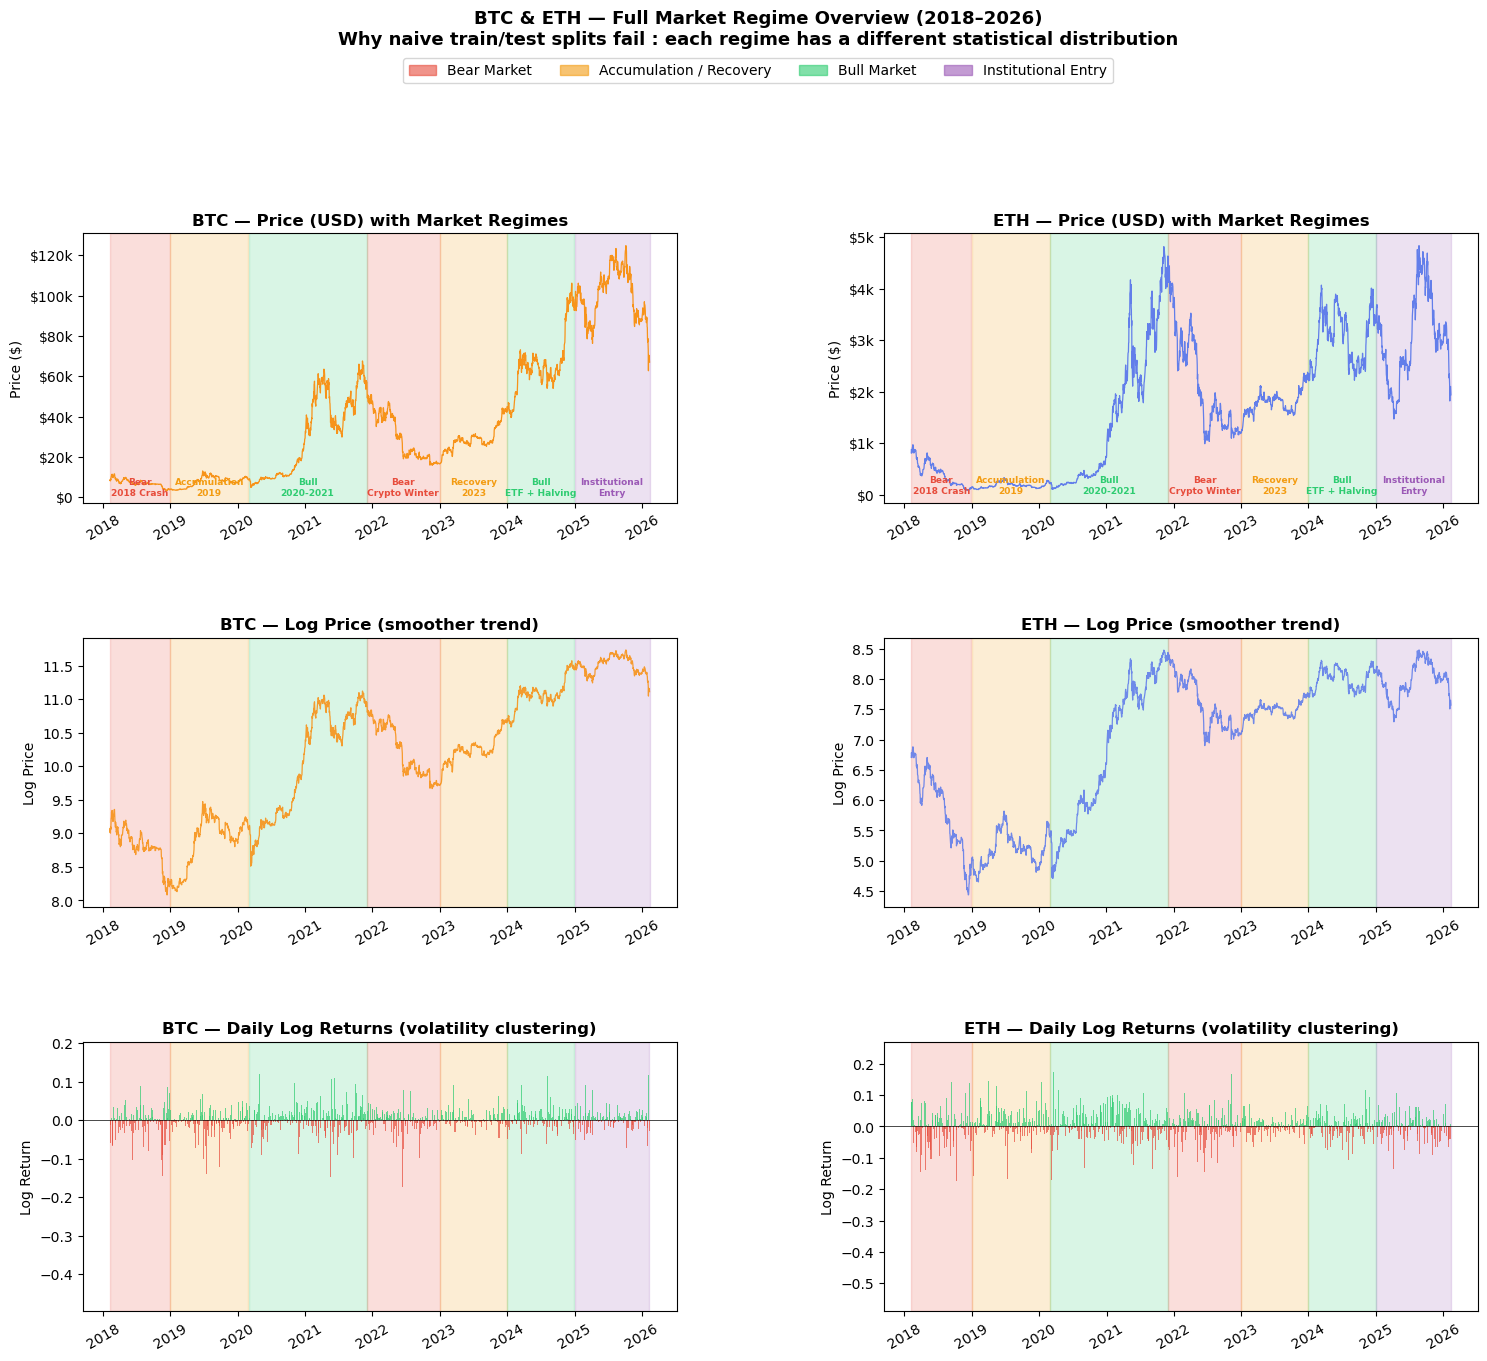

In [57]:
# EDA — MARKET REGIME VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# ── Define regime periods ─────────────────────────────────────
regimes = [
    ("2018-02-08", "2018-12-31", "#e74c3c", "Bear\n2018 Crash",        0.15),
    ("2019-01-01", "2020-02-28", "#f39c12", "Accumulation\n2019",       0.15),
    ("2020-03-01", "2021-11-30", "#2ecc71", "Bull\n2020-2021",          0.15),
    ("2021-12-01", "2022-12-31", "#e74c3c", "Bear\nCrypto Winter",      0.15),
    ("2023-01-01", "2023-12-31", "#f39c12", "Recovery\n2023",           0.15),
    ("2024-01-01", "2024-12-31", "#2ecc71", "Bull\nETF + Halving",      0.15),
    ("2025-01-01", "2026-02-11", "#9b59b6", "Institutional\nEntry",     0.15),
]

colors  = {"btc": "#F7931A", "eth": "#627EEA"}
fig     = plt.figure(figsize=(18, 14))
gs      = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

for i, coin in enumerate(["btc", "eth"]):
    sub = df[df["coin"] == coin].set_index("timestamp").sort_index()

    # ── Price with regime shading ─────────────────────────────
    ax1 = fig.add_subplot(gs[0, i])
    for start, end, color, label, alpha in regimes:
        ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    color=color, alpha=0.18)
        mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
        ax1.text(mid, ax1.get_ylim()[1] if i == 0 else ax1.get_ylim()[1],
                 label, ha="center", fontsize=6.5, color=color,
                 fontweight="bold", va="bottom")
    ax1.plot(sub.index, sub["price"], color=colors[coin], linewidth=0.9)
    ax1.set_title(f"{coin.upper()} — Price (USD) with Market Regimes",
                  fontweight="bold")
    ax1.set_ylabel("Price ($)")
    ax1.tick_params(axis="x", rotation=30)
    ax1.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k" if x >= 1000 else f"${x:.0f}")
    )

    # ── Log price ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, i])
    for start, end, color, label, alpha in regimes:
        ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    color=color, alpha=0.18)
    ax2.plot(sub.index, sub["log_price"], color=colors[coin],
             linewidth=0.9, alpha=0.9)
    ax2.set_title(f"{coin.upper()} — Log Price (smoother trend)",
                  fontweight="bold")
    ax2.set_ylabel("Log Price")
    ax2.tick_params(axis="x", rotation=30)

    # ── Daily log returns (volatility clustering) ─────────────
    ax3 = fig.add_subplot(gs[2, i])
    for start, end, color, label, alpha in regimes:
        ax3.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    color=color, alpha=0.18)
    ax3.bar(sub.index, sub["log_return_1d"],
            color=sub["log_return_1d"].apply(
                lambda x: "#2ecc71" if x >= 0 else "#e74c3c"),
            width=1.5, alpha=0.7)
    ax3.axhline(0, color="black", linewidth=0.5)
    ax3.set_title(f"{coin.upper()} — Daily Log Returns (volatility clustering)",
                  fontweight="bold")
    ax3.set_ylabel("Log Return")
    ax3.tick_params(axis="x", rotation=30)

# ── Shared legend ─────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color="#e74c3c", alpha=0.6, label="Bear Market"),
    mpatches.Patch(color="#f39c12", alpha=0.6, label="Accumulation / Recovery"),
    mpatches.Patch(color="#2ecc71", alpha=0.6, label="Bull Market"),
    mpatches.Patch(color="#9b59b6", alpha=0.6, label="Institutional Entry"),
]
fig.legend(handles=legend_patches, loc="upper center",
           ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.01),
           frameon=True)

plt.suptitle(
    "BTC & ETH — Full Market Regime Overview (2018–2026)\n"
    "Why naive train/test splits fail : each regime has a different statistical distribution",
    fontsize=13, fontweight="bold", y=1.04
)

plt.show()


- Price (Row 1)
BTC and ETH are not stationary they move in distinct regimes with completely different price levels, trends and volatility. A model trained on one regime is essentially blind to the next.
- Log Price (Row 2)
Log scale reveals that the structure of cycles is actually consistent each bull run is roughly a log-linear climb, each crash a sharp log-linear drop. This is why log_price and log_return are better model inputs than raw price.
- Daily Returns (Row 3)
Three things jump out immediately:

- Volatility clustering : big moves come in clusters, not randomly. High volatility days are surrounded by high volatility days. This is the signature of a non-IID process .classical ML models that assume independence between samples will struggle.
Fat tails the extreme spikes in 2020 (COVID crash) and 2021/2022 are far beyond what a normal distribution would predict.
Regime asymmetry bear markets produce larger negative spikes than bull markets produce positive ones.

- The core modeling problem
2018-2019  →  bear/accumulation  →  low volatility, downtrend
2020-2021  →  bull              →  high volatility, uptrend
2022       →  crypto winter     →  extreme volatility, crash
2023-2024  →  recovery/bull     →  moderate volatility, uptrend
2025-2026  →  institutional     →  different volatility structure

- conclusion : A random 80/20 split would mix these regimes — the model would leak future regime information into training. We need a chronological split, and possibly walk-forward validation. This is what we address next when we define the train/val/test boundaries.

### Our solutions for theese issues :

1. Chronological Train / Val / Test Split
Never shuffle. Split strictly by time:

- 2018-02-08 → 2022-12-31  →  Train   (covers bear + bull + crash)
- 2023-01-01 → 2023-12-31  →  Val     (recovery regime)
- 2024-01-01 → 2026-02-11  →  Test    (institutional regime)
This respects the temporal structure and tests on the most recent unseen regime (the hardest and most honest evaluation.)

2. Walk-Forward Validation:

Instead of one fixed split, train on a window, validate on the next window, slide forward. Gives a more robust estimate of real-world performance across multiple regimes.
- Train [2018→2021] → Val [2022]
- Train [2018→2022] → Val [2023]
- Train [2018→2023] → Val [2024]

3. Regime-Aware Features
We already have some of these — vix_regime, fear_greed_cat. We can add:

- A bull/bear flag derived from price_to_ma50 (price above MA50 = bull)
- A volatility regime from volatility_21d (high/low relative to rolling median)

These help the model know which regime it's in rather than trying to figure it out from raw price alone.


4. Target : Direction Instead of Magnitude
- Predicting exact log return is very hard across regimes. Predicting direction (up/down next day) is more regime-stable and gives us a classification problem which is generally more robust.

Decision : 

- Primary model   → Classification (up/down)
- Evaluation      → Walk-forward validation
- Features        → Add regime flags (bull/bear + volatility regime)

In [61]:
# ============================================================
# FEATURE CHECK — CURRENT STATE
# ============================================================

feature_cols = [c for c in df.columns
                if c not in ["timestamp", "coin", "price", "volume"]]

print(f"Total features : {len(feature_cols)}")
print(f"\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"  {i:02d}. {col}")

Total features : 38

All columns:
  00. timestamp
  01. price
  02. volume
  03. coin
  04. spy_return
  05. dxy_return
  06. vix
  07. vix_change
  08. fear_greed
  09. rsi_14
  10. log_return_1d
  11. volatility_7d
  12. volatility_14d
  13. ma_7
  14. ma_14
  15. ma_30
  16. price_to_ma7
  17. price_to_ma30
  18. macd
  19. macd_signal
  20. macd_histogram
  21. momentum_5d
  22. momentum_10d
  23. momentum_acceleration
  24. fear_greed_cat
  25. spy_return_ma7
  26. spy_return_std7
  27. dxy_return_ma7
  28. vix_ma14
  29. vix_regime
  30. fear_greed_ma7
  31. fear_greed_lag1
  32. fear_greed_lag7
  33. log_price
  34. log_volume
  35. ma_50
  36. price_to_ma50
  37. bb_width
  38. bb_pct
  39. volatility_21d
  40. bull_bear_flag
  41. volatility_regime


## features inventory : 
| Base | Trend | Momentum | Volatility | Macro | Sentiment | Regime flags |
|------|-------|----------|------------|-------|-----------|--------------|
| timestamp | ma_7 | macd | volatility_7d | spy_return | fear_greed | bull_bear_flag |
| price | ma_14 | macd_signal | volatility_14d | spy_return_ma7 | fear_greed_ma7 | volatility_regime |
| volume | ma_30 | macd_histogram | volatility_21d | spy_return_std7 | fear_greed_lag1 | - |
| coinTransformed | ma_50 | rsi_14 | bb_width | dxy_return | fear_greed_lag7 | - |
| log_price | price_to_ma7 | momentum_5d | bb_pct | dxy_return_ma7 | fear_greed_cat | - |
| log_volume | price_to_ma30 | momentum_10d | - | vix | - | - |
| log_return_1d | price_to_ma50 | momentum_acceleration | - | vix_change | - | - |
| - | - | - | - | vix_ma14 | - | - |
| - | - | - | - | vix_regime | - | - |


### Bitcoin vs Ethereum Price Over Time

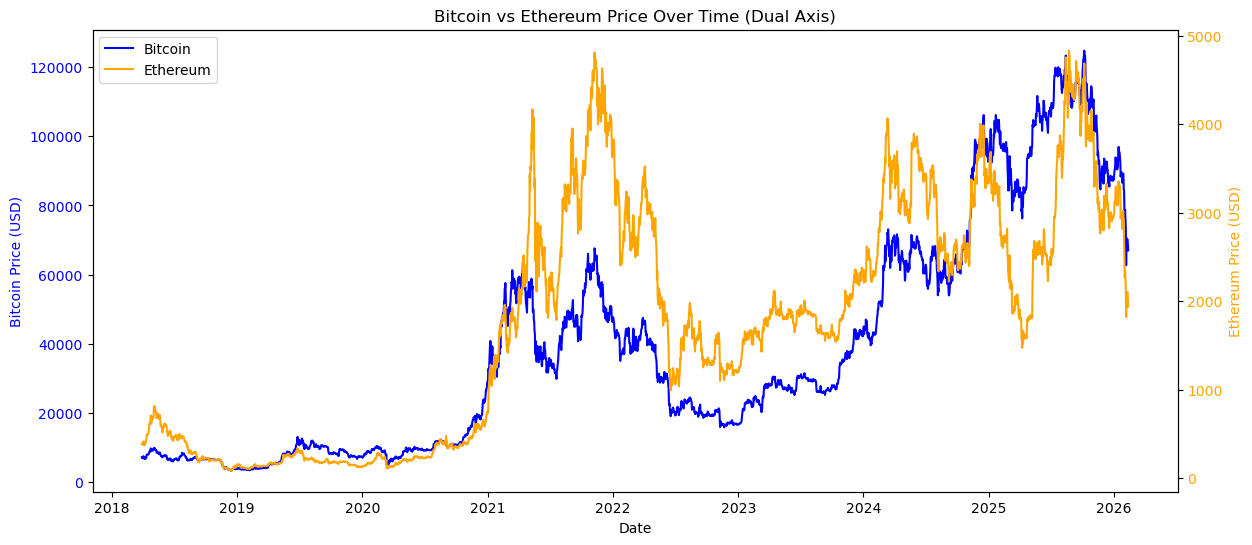

In [63]:
import matplotlib.pyplot as plt
#price over time 
plt.figure(figsize=(14,6))

# Separate data
btc = df[df['coin'] == 'btc']
eth = df[df['coin'] == 'eth']

# Plot Bitcoin
ax = plt.gca()
ax.plot(btc['timestamp'], btc['price'], color='blue', label='Bitcoin')
ax.set_ylabel('Bitcoin Price (USD)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# Plot Ethereum on secondary axis
ax2 = ax.twinx()
ax2.plot(eth['timestamp'], eth['price'], color='orange', label='Ethereum')
ax2.set_ylabel('Ethereum Price (USD)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("Bitcoin vs Ethereum Price Over Time (Dual Axis)")
ax.set_xlabel("Date")

# Legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()


- Co-movement: Many price spikes in Bitcoin coincide with similar spikes in Ethereum suggesting a correlation between the two coins, likely due to market sentiment and shared investor base (btc movement could serve as a predictive feature for Ethereum in ML models and vice versa)
- Volatility: Ethereum's price appears more jagged compared to Bitcoin confirming its higher volatility

### Daily Log Return Over Time zoom (2025-2026)

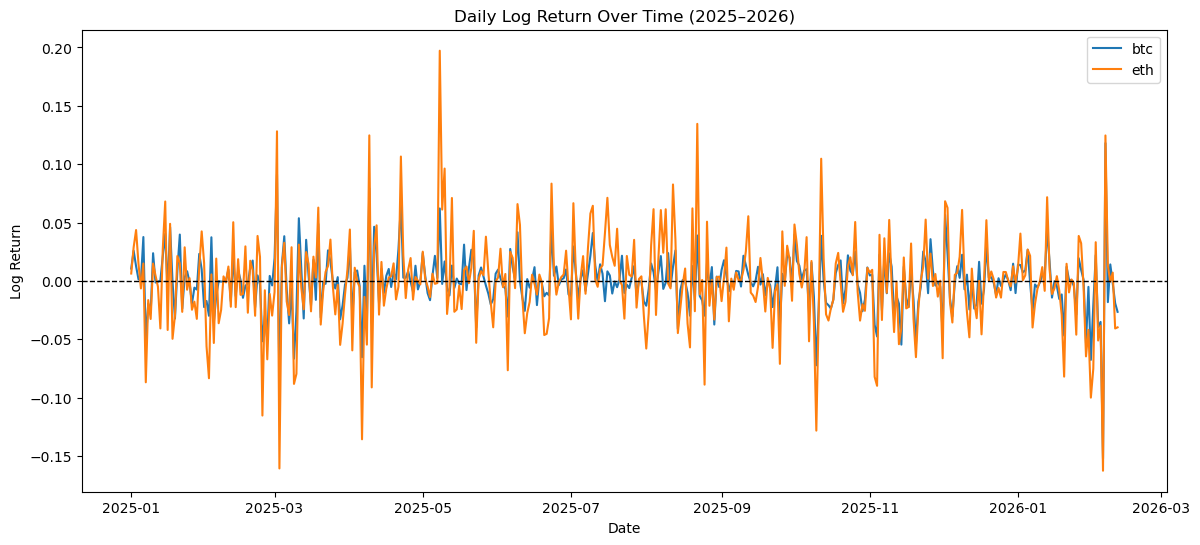

In [68]:
plt.figure(figsize=(14, 6))

for coin in df["coin"].unique():
    coin_df = df[
        (df["coin"] == coin) &
        (df["timestamp"] >= "2025-01-01")
    ]
    plt.plot(coin_df["timestamp"], coin_df["log_return_1d"], label=coin)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Daily Log Return Over Time (2025–2026)")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()

- Log Return:

Ethereum shows larger daily swings (both positive and negative) compared to Bitcoin, confirming higher daily volatility.
Spikes indicate sudden market movements potential risk periods or trading opportunities.

### ROLLING VOLATILITY zoom (2025-2026)

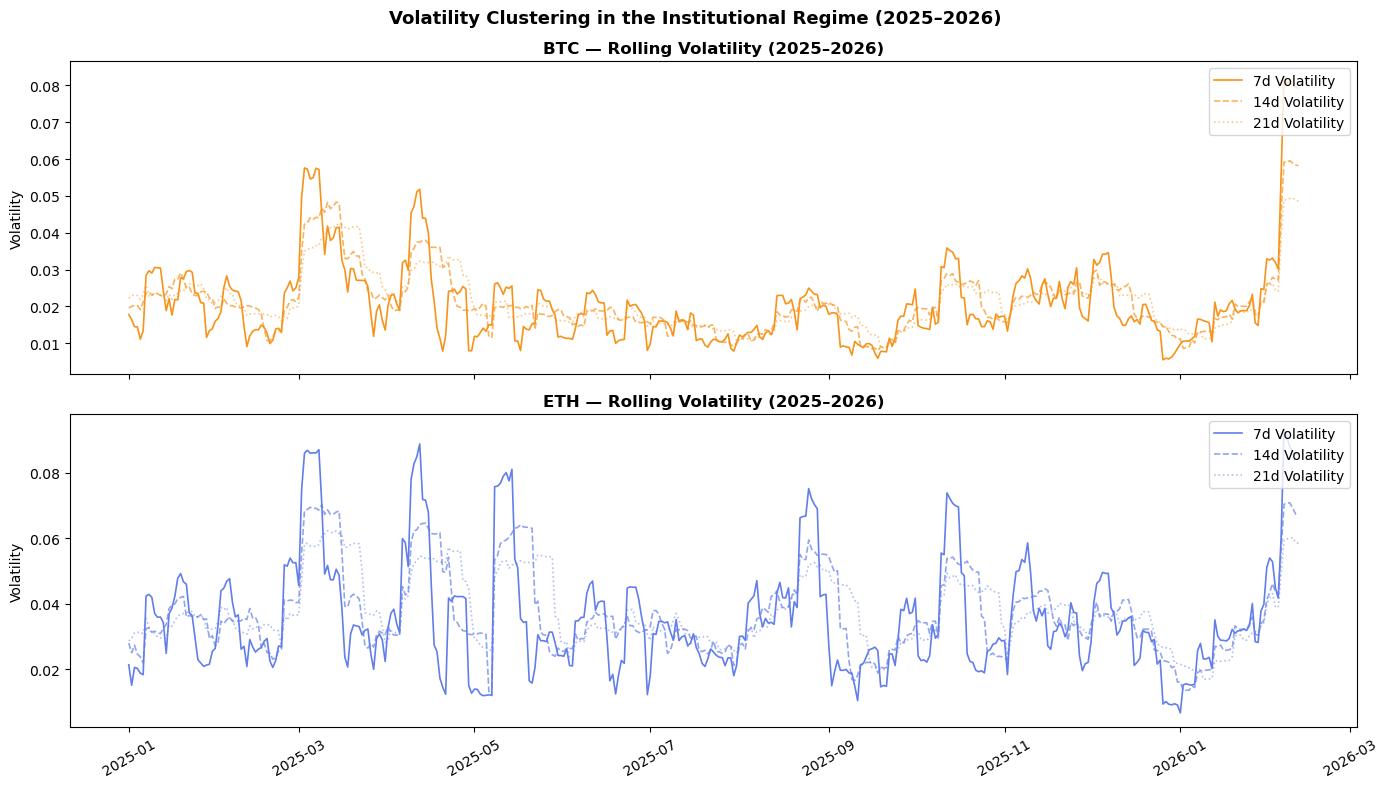

In [66]:


fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors = {"btc": "#F7931A", "eth": "#627EEA"}

for ax, coin in zip(axes, ["btc", "eth"]):
    sub = df[
        (df["coin"] == coin) &
        (df["timestamp"] >= "2025-01-01")
    ].set_index("timestamp")

    ax.plot(sub.index, sub["volatility_7d"],
            color=colors[coin], linewidth=1.2,
            label="7d Volatility")
    ax.plot(sub.index, sub["volatility_14d"],
            color=colors[coin], linewidth=1.2,
            linestyle="--", alpha=0.7,
            label="14d Volatility")
    ax.plot(sub.index, sub["volatility_21d"],
            color=colors[coin], linewidth=1.2,
            linestyle=":", alpha=0.5,
            label="21d Volatility")

    ax.set_title(f"{coin.upper()} — Rolling Volatility (2025–2026)",
                 fontweight="bold")
    ax.set_ylabel("Volatility")
    ax.legend(loc="upper right")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Volatility Clustering in the Institutional Regime (2025–2026)",
             fontsize=13, fontweight="bold")
plt.tight_layout()

plt.show()

- Rolling Volatility:

Bitcoin’s rolling volatility is relatively stable, Ethereum’s volatility fluctuates more widely.
7day vs 14day: shorter windows capture quick spikes, longer windows smooth the noise and show trend volatility
Log returns and rolling volatility are key inputs for LSTM models because they represent normalized price movement and risk dynamics..

### price moving average (MA) zoom (2025-2026)

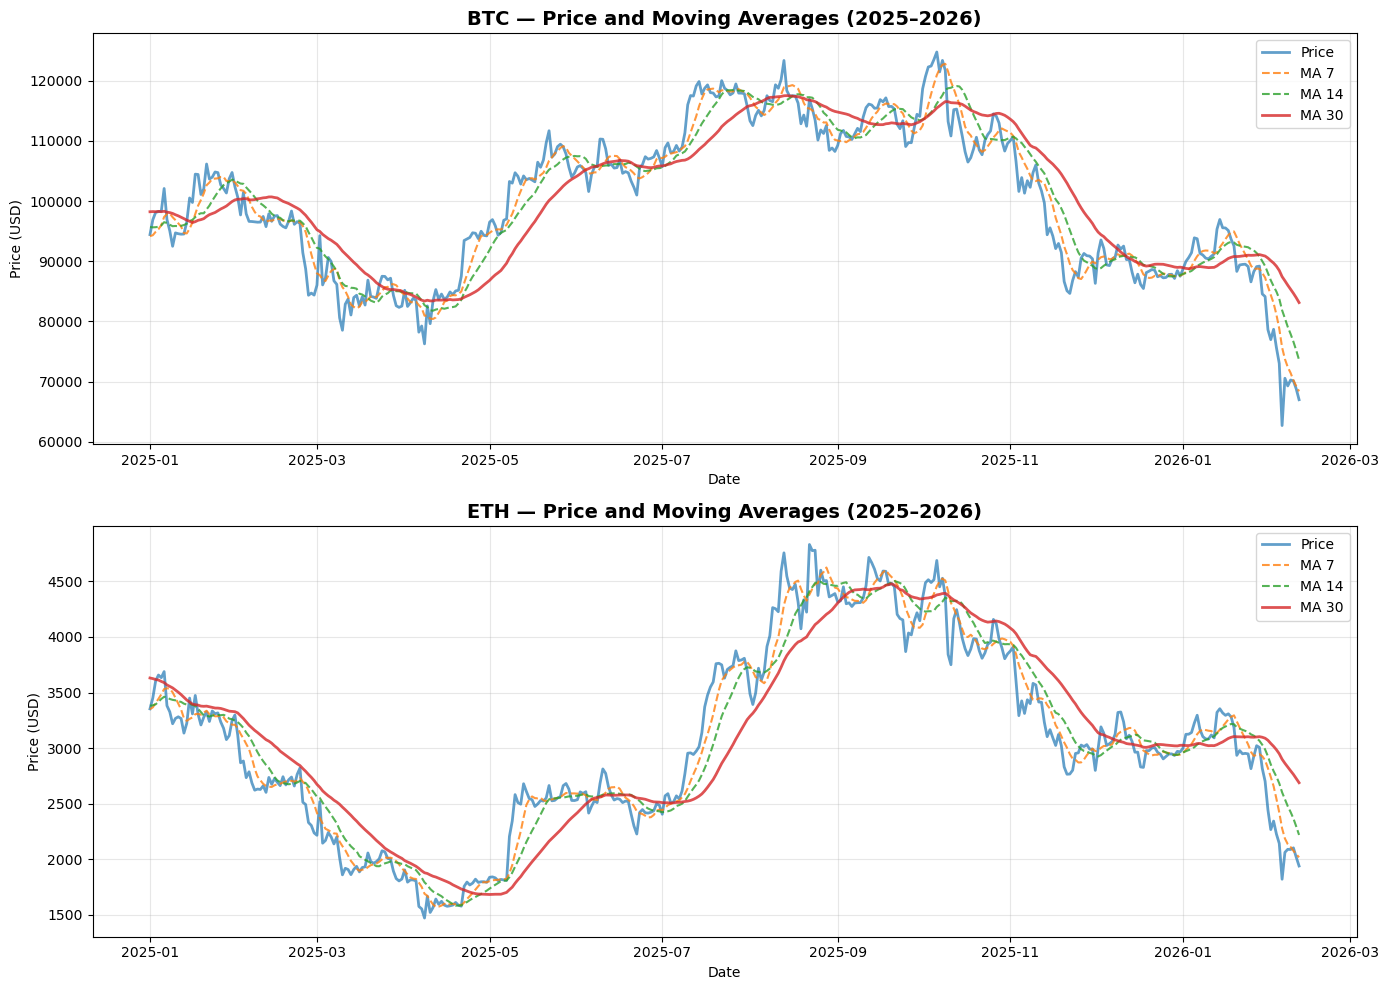

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[
        (df["coin"] == coin_name) &
        (df["timestamp"] >= "2025-01-01")
    ].copy()

    ax = axes[idx]
    ax.plot(coin_data["timestamp"], coin_data["price"],  label="Price", linewidth=2, alpha=0.7)
    ax.plot(coin_data["timestamp"], coin_data["ma_7"],   label="MA 7",  linestyle="--", alpha=0.8)
    ax.plot(coin_data["timestamp"], coin_data["ma_14"],  label="MA 14", linestyle="--", alpha=0.8)
    ax.plot(coin_data["timestamp"], coin_data["ma_30"],  label="MA 30", linestyle="-",  linewidth=2, alpha=0.8)

    ax.set_title(f"{coin_name.upper()} — Price and Moving Averages (2025–2026)",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- MA30 (long-term) → Smoothest, shows overall trend direction
- MA14 (medium-term) → Less smooth, reacts faster to changes
- MA7 (short-term) → Captures short-term volatility and price swings

1. MA Crossovers: 
- MA7 crosses above MA30 → Bullish signal (uptrend starting)
- MA7 crosses below MA30 → Bearish signal (downtrend starting)

2. Price Position Relative to MAs, When price is:
- Above all MAs → Strong uptrend, bullish momentum
- Below all MAs → Strong downtrend, bearish momentum
- Between MAs → Transition/consolidation phase, uncertainty

3. MA Spread (Distance Between MAs)
- Wide spread (MA7 far from MA30) → Strong trend (up or down)
- Narrow spread (MAs converging) → Weak trend, possible reversal coming

4. Support/Resistance Levels , MAs often act as:
- Support during uptrends (price bounces off MA30)
- Resistance during downtrends (price struggles to cross above MA30)

### Price relative to MA30 (shows when price is above/below long-term trend)

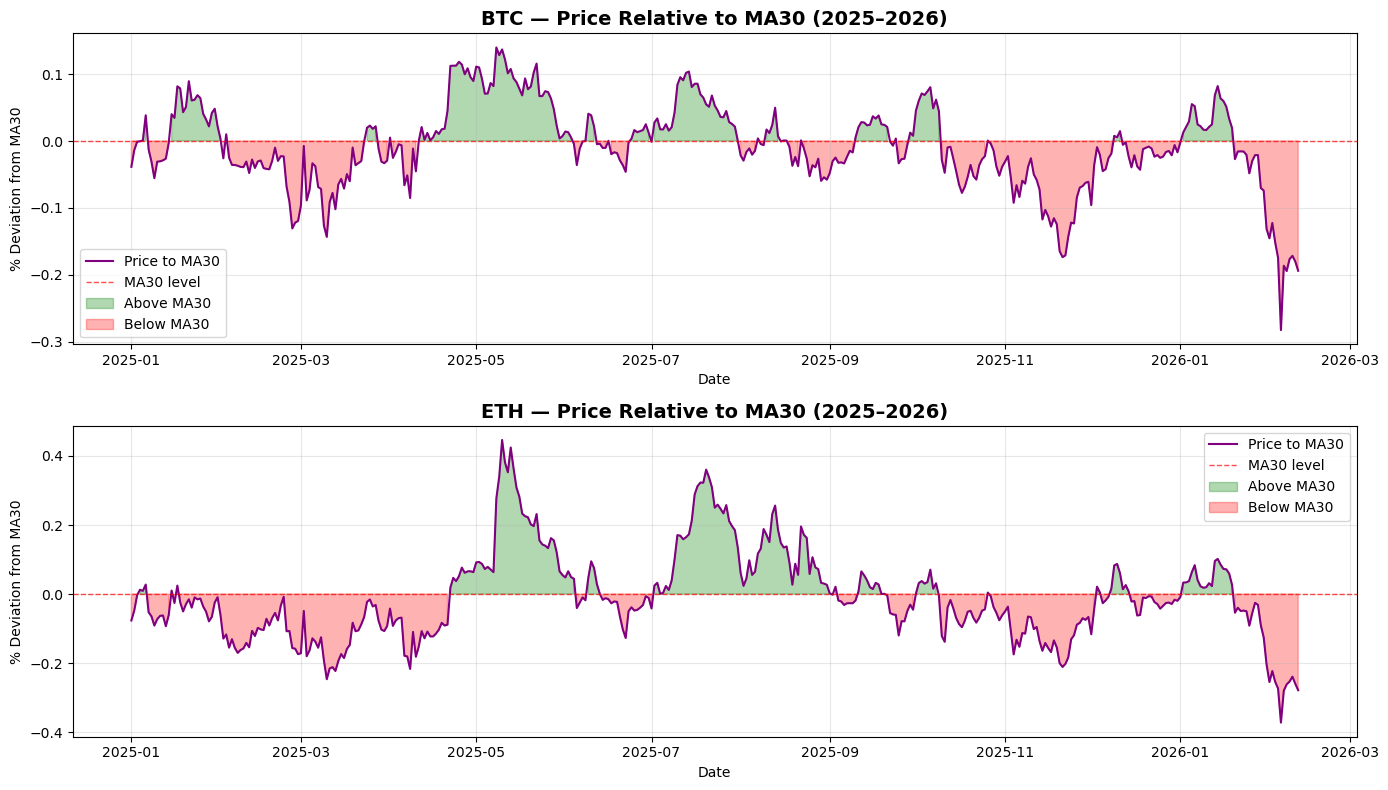

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[
        (df["coin"] == coin_name) &
        (df["timestamp"] >= "2025-01-01")
    ].copy()

    ax = axes[idx]
    ax.plot(coin_data["timestamp"], coin_data["price_to_ma30"],
            label="Price to MA30", color="purple")
    ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="MA30 level")
    ax.fill_between(coin_data["timestamp"], 0, coin_data["price_to_ma30"],
                    where=(coin_data["price_to_ma30"] > 0),
                    color="green", alpha=0.3, label="Above MA30")
    ax.fill_between(coin_data["timestamp"], 0, coin_data["price_to_ma30"],
                    where=(coin_data["price_to_ma30"] < 0),
                    color="red", alpha=0.3, label="Below MA30")

    ax.set_title(f"{coin_name.upper()} — Price Relative to MA30 (2025–2026)",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("% Deviation from MA30")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Lag Effect

- MA30 lags behind price movements during crashes, MA30 stays high while price drops → creates the gap in price relative to MA30 
- % deviation from 30-day trend: Green zone = price above trend (bullish) there is probability of bounce back
- % deviation from 30-day trend:Red zone = price below trend (bearish) there is probability of pull back
- When very negative (-0.20) → Bounce back happens → Mean reversion

### MACD INDICATORS

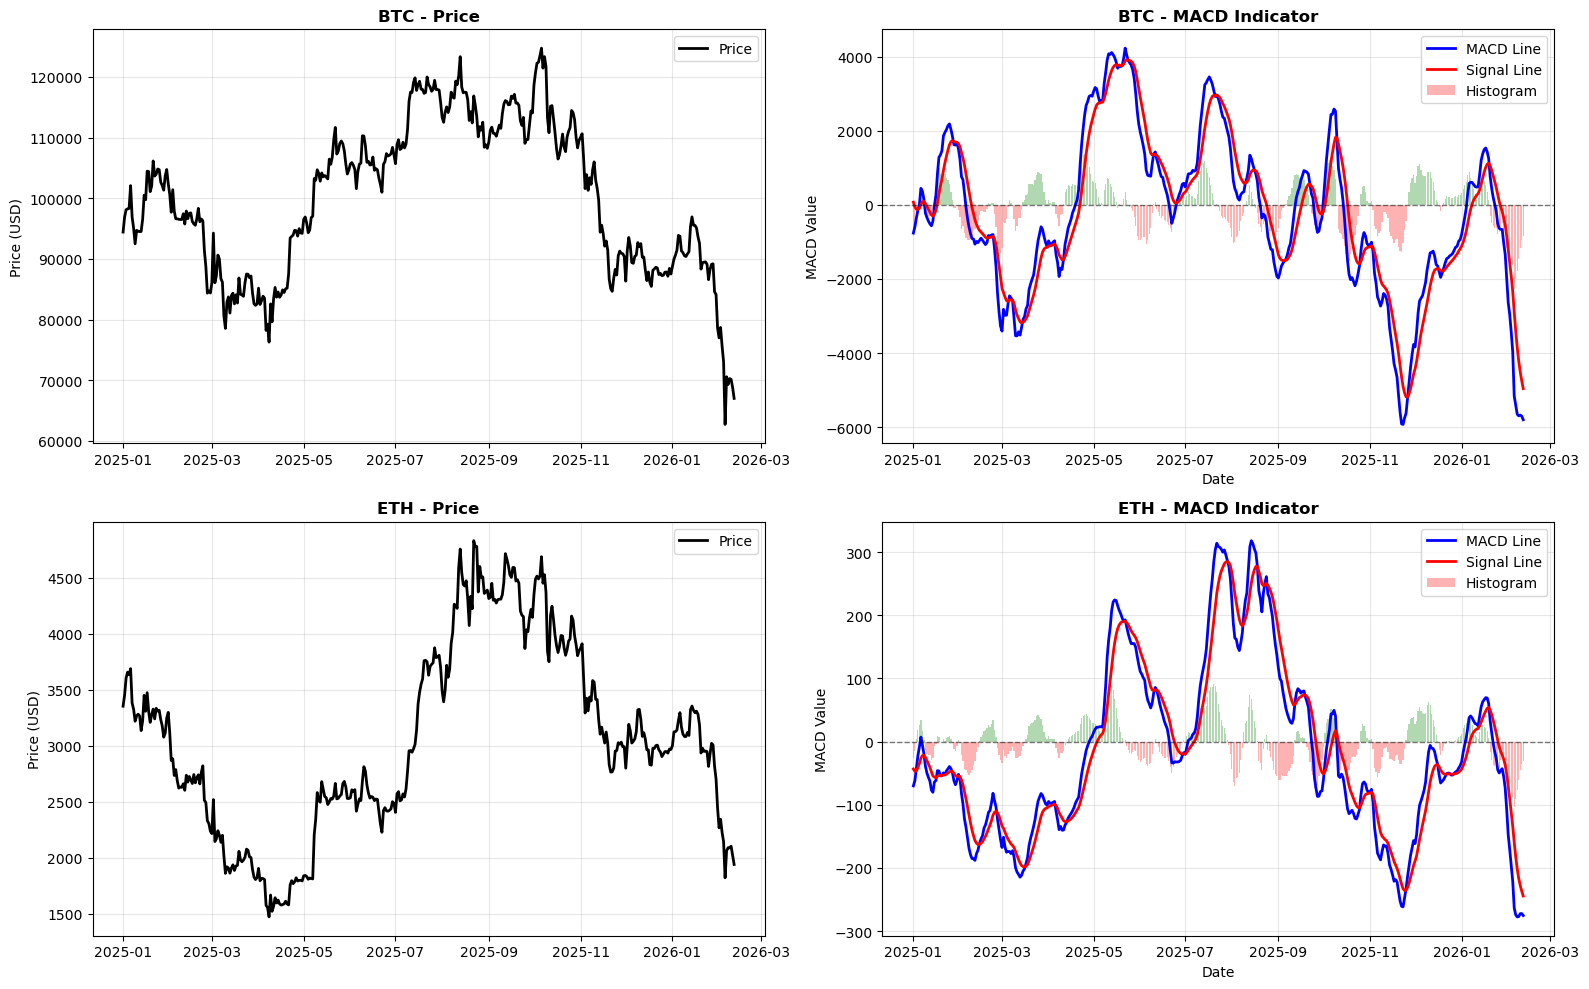

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[
        (df["coin"] == coin_name) &
        (df["timestamp"] >= "2025-01-01")
    ].copy()

    
    # Top plot: Price
    ax_price = axes[idx, 0]
    ax_price.plot(coin_data["timestamp"], coin_data["price"], label="Price", linewidth=2, color="black")
    ax_price.set_title(f"{coin_name.upper()} - Price", fontsize=12, fontweight="bold")
    ax_price.set_ylabel("Price (USD)")
    ax_price.legend()
    ax_price.grid(alpha=0.3)
    
    # Bottom plot: MACD
    ax_macd = axes[idx, 1]
    ax_macd.plot(coin_data["timestamp"], coin_data["macd"], label="MACD Line", linewidth=2, color="blue")
    ax_macd.plot(coin_data["timestamp"], coin_data["macd_signal"], label="Signal Line", linewidth=2, color="red")
    ax_macd.bar(coin_data["timestamp"], coin_data["macd_histogram"], label="Histogram", 
                alpha=0.3, color=coin_data["macd_histogram"].apply(lambda x: "green" if x > 0 else "red"))
    ax_macd.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax_macd.set_title(f"{coin_name.upper()} - MACD Indicator", fontsize=12, fontweight="bold")
    ax_macd.set_xlabel("Date")
    ax_macd.set_ylabel("MACD Value")
    ax_macd.legend()
    ax_macd.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. MACD Crossovers Work! that is a sweet pot for the prediction of price movements as it is a leading indicator that captures momentum shifts before they happen in the price action.
- Blue ( MACD) crosses above red (SIgnal Line)  → Price goes up 
- Blue ( MACD) crosses below red (SIgnal Line) → Price goes down 
- Crossover happens BEFORE price reversal (predictor)
- Lagging = Crossover happens AFTER price already moved (confirmation)

### MACD Histogram (Momentum Strength)

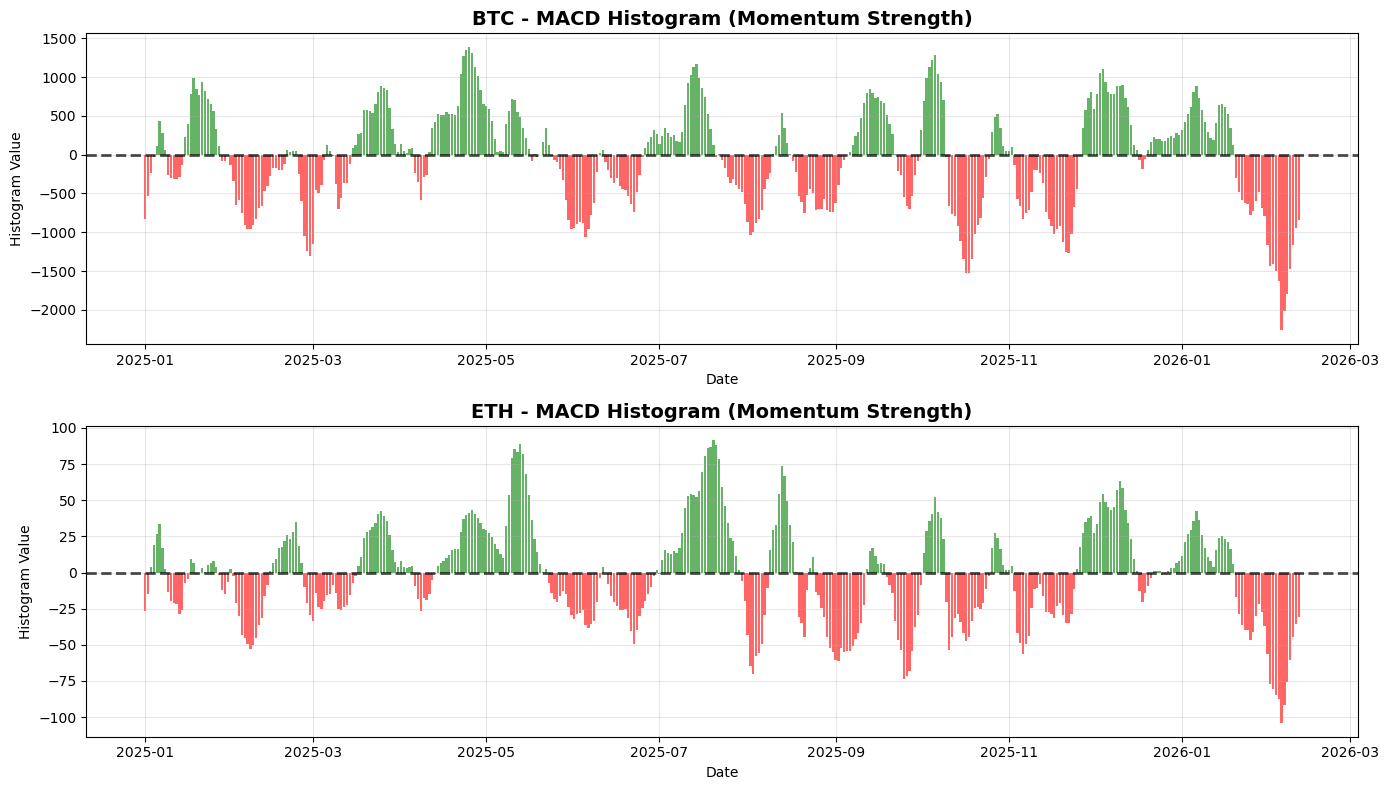

In [72]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[
        (df["coin"] == coin_name) &
        (df["timestamp"] >= "2025-01-01")
    ].copy()
    
    ax = axes[idx]
    # Color bars: green = bullish momentum, red = bearish momentum
    colors = coin_data["macd_histogram"].apply(lambda x: "green" if x > 0 else "red")
    ax.bar(coin_data["timestamp"], coin_data["macd_histogram"], color=colors, alpha=0.6)
    ax.axhline(0, color="black", linestyle="--", linewidth=2, alpha=0.7)
    
    ax.set_title(f"{coin_name.upper()} - MACD Histogram (Momentum Strength)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Histogram Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- MACD histogram peaks (Momentum Exhaustion) SignalBEFORE price bottoms/tops (leading reversal signal)
- Green bars getting taller = Bulls accelerating (buying pressure increasing)
- Peak green bar = Maximum bullish momentum ,bars start shrinking after peak = Bulls getting tired .Signal: Uptrend losing steam → Reversal down coming soon
- Red bars getting taller = Bears accelerating (selling pressure increasing) . Peak red bar = Maximum bearish momentum
Bars start shrinking after peak = Bears getting tired . Signal: Downtrend losing steam → Reversal up coming soon!